# Stock Market Prediction Using Machine Learning and Ensemble Learning

## Imports

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import (LinearRegression,Ridge,Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split,TimeSeriesSplit,cross_validate,GridSearchCV)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme()

## Data Processing


In [12]:
# Ticker = input(print('Enter Ticker: '))
Ticker ='TSLA'

df = yf.download(Ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [13]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [14]:
df['Target'] = df['Close'].shift(-1)
df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500,29.534000
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500,30.102667
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000,31.270666
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500,32.809334
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500,32.089333


In [15]:

df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()


df['Volatility'] = df['Close'].rolling(10).std()


df['Daily_Return'] = df['Close'].pct_change()

In [16]:
df.dropna(axis=0,inplace=True)

In [17]:
df.describe()

Price,Close,High,Low,Open,Volume,Target,MA_10,MA_50,Volatility,Daily_Return
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
count,1612.000000,1612.000000,1612.000000,1612.000000,1.612000e+03,1612.000000,1612.000000,1612.000000,1612.000000,1612.000000
mean,258.111747,263.754744,252.268870,258.193738,1.087585e+08,258.300034,257.319349,253.425986,11.360644,0.002141
std,98.879169,100.744924,97.088516,99.047990,6.287266e+07,98.745691,98.666606,97.222135,6.732828,0.039925
min,24.081333,26.990667,23.367332,24.980000,2.334520e+07,24.081333,30.751467,41.833187,0.580840,-0.210628
25%,194.770004,198.980000,190.347507,195.077499,6.811102e+07,194.837502,194.673500,192.055451,6.674539,-0.020159
50%,245.618332,251.373337,240.714996,245.269997,9.376550e+07,245.886665,245.657498,244.509800,9.873070,0.001510
75%,328.519997,335.664169,321.452507,328.477509,1.270194e+08,328.680824,326.189332,319.422100,14.535904,0.022371
max,489.880005,498.829987,485.329987,489.880005,6.663786e+08,489.880005,479.154004,445.266002,40.447100,0.226900


In [18]:
df.isnull().sum()


Price         Ticker
Close         TSLA      0
High          TSLA      0
Low           TSLA      0
Open          TSLA      0
Volume        TSLA      0
Target                  0
MA_10                   0
MA_50                   0
Volatility              0
Daily_Return            0
dtype: int64

## Feature Selection

In [19]:
target = df['Target']
features = df[['Close','Volume','High','Low','Open',
         'MA_10','MA_50',
         'Volatility']]

## Train Test Split

In [20]:
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size = 0.2,shuffle = False)

## Cross Validation

In [21]:
# TimeSeries Split
tscv = TimeSeriesSplit(n_splits=5)

scoring = {
    'R2':'r2',
    'MAE':'neg_mean_absolute_error',
    'RMSE':'neg_root_mean_squared_error'
}

def run_cross_validation(model,x,y):
    scores = cross_validate(
        model,
        x,
        y,
        cv = tscv,
        scoring = scoring
    )

    print(f"Average R2 : {scores["test_R2"].mean():.2f}")
    print(f"Average MAE : {-scores["test_MAE"].mean():.2f}")
    print(f"Average RMSE : {-scores["test_RMSE"].mean():.2f}")


# Model Selection

## Linear Regression

In [22]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

run_cross_validation(lr,x_train,y_train)

Average R2 : 0.96
Average MAE : 7.27
Average RMSE : 9.79


## Ridge Regression

In [23]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

run_cross_validation(ridge,x_train,y_train)

Average R2 : 0.95
Average MAE : 7.45
Average RMSE : 9.94


## Lasso Regression


In [24]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

run_cross_validation(lasso,x_train,y_train)

Average R2 : 0.96
Average MAE : 7.14
Average RMSE : 9.66


##  Random Forest

In [25]:
rf = RandomForestRegressor(
    random_state=42,
)

run_cross_validation(rf,x_train,y_train)

Average R2 : 0.80
Average MAE : 14.89
Average RMSE : 20.23


## XG Boost Regressor

In [26]:
xgb = XGBRegressor(
    random_state=42,
)

run_cross_validation(xgb,x_train,y_train)

Average R2 : 0.82
Average MAE : 13.91
Average RMSE : 20.31


## Hyperparameter Tuning with GridSearchCV For Linear Regression

In [27]:
param_grid = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__fit_intercept': True, 'model__positive': True}
Best CV RMSE:
9.770806284142996


In [28]:
best_lr = grid_search.best_estimator_

run_cross_validation(
    best_lr,
    x_train,
    y_train
)

Average R2 : 0.96
Average MAE : 7.27
Average RMSE : 9.77


In [29]:
joblib.dump(best_lr,"../model/model.pkl")

['../model/model.pkl']

## Training Best Model (Linear Regression)

In [30]:
best_lr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](8,)","[2.26e+02,1.17e+08,2.31e+02,...,2.25e+02,2.22e+02,1.08e+01]"


In [31]:
y_pred = best_lr.predict(x_test)

## LR Evaluation

In [32]:
test_r2 = r2_score(y_test,y_pred)
test_mae = mean_absolute_error(y_test,y_pred)
test_mse = mean_squared_error(y_test,y_pred)
test_rmse = np.sqrt(test_mse)

print(f"R2 : {test_r2:.2f}")
print(f"MAE : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")

R2 : 0.95
MAE : 9.14
RMSE : 11.83


In [34]:
naive_pred = x_test['Close'].values

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"Naive MAE  : {naive_mae:.2f}")
print(f"Naive RMSE : {naive_rmse:.2f}")

Naive MAE  : 8.99
Naive RMSE : 11.73


## Neural Network


In [36]:
validation_size = int(len(x_train) * 0.2)

x_train_nn = x_train.iloc[:-validation_size]
x_val_nn = x_train.iloc[-validation_size:]

y_train_nn = y_train[:-validation_size]
y_val_nn = y_train[-validation_size:]

In [38]:
nn_scaler = StandardScaler()

x_train_nn_scaled = nn_scaler.fit_transform(x_train_nn)
x_val_nn_scaled = nn_scaler.transform(x_val_nn)
x_test_nn_scaled = nn_scaler.transform(x_test)

In [39]:
## Save the scaler
joblib.dump(nn_scaler, "../model/nn_scaler.pkl")

['../model/nn_scaler.pkl']

In [62]:
model = keras.Sequential([
    layers.Input(shape = (x_train_nn_scaled.shape[1],)),
    layers.Dense(32,activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16,activation='relu'),
    layers.Dense(1)
])

In [68]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0005),
    loss = 'mse',
    metrics = ['mae']
)

In [69]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

### Training

In [70]:
history = model.fit(
    x_train_nn_scaled,
    y_train_nn,
    validation_data= ( x_val_nn_scaled,y_val_nn ),
    epochs=100,
    batch_size=32,
    shuffle= False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 343.0424 - mae: 14.3405 - val_loss: 207.7702 - val_mae: 10.3342
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 317.4005 - mae: 13.5616 - val_loss: 202.8371 - val_mae: 10.1863
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 329.9071 - mae: 13.8223 - val_loss: 203.3213 - val_mae: 10.1705
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 335.8235 - mae: 14.0449 - val_loss: 201.6448 - val_mae: 10.1314
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 335.6132 - mae: 13.9936 - val_loss: 198.4428 - val_mae: 10.0267
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 298.1492 - mae: 13.3657 - val_loss: 197.2147 - val_mae: 10.0221
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 280.4186 - mae: 12.8451 - val_loss: 201.2070 - val_mae: 10.0624
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 310.9926 - mae: 13.4285 - val_loss: 198.1216 - val_mae: 9.9693
Epoch 9/100
33/3

## NN Evaluation

In [71]:
y_pred_nn = model.predict(
    x_test_nn_scaled,
    verbose=0
).ravel()

In [72]:
nn_r2 = r2_score(y_test,y_pred_nn)
nn_mae = mean_absolute_error(y_test,y_pred_nn)
nn_mse = mean_squared_error(y_test,y_pred_nn)
nn_rmse = np.sqrt(nn_mse)

print(f"R2 :{nn_r2:.2f}")
print(f"MAE :{nn_mae:.2f}")
print(f"RMSE :{nn_rmse:.2f}")


R2 :0.94
MAE :9.55
RMSE :12.22


In [73]:
## Save Model
joblib.dump(model,"../model/nn_model.pkl")

['../model/nn_model.pkl']

# Visualizations

## Correlation Heatmap

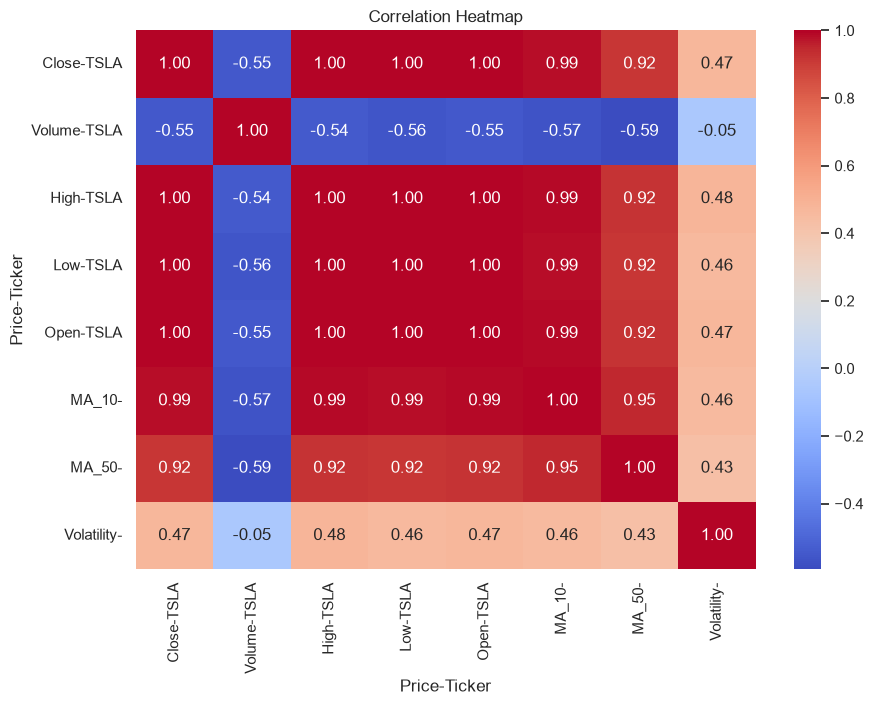

In [77]:

plt.figure(figsize=(10,7))

sns.heatmap(features.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png",dpi=300,bbox_inches='tight')
plt.show()